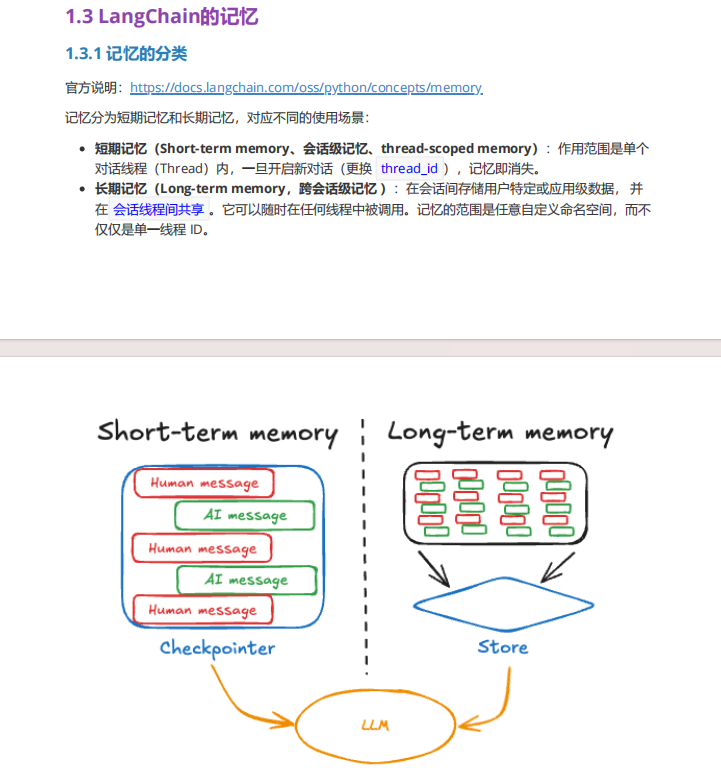
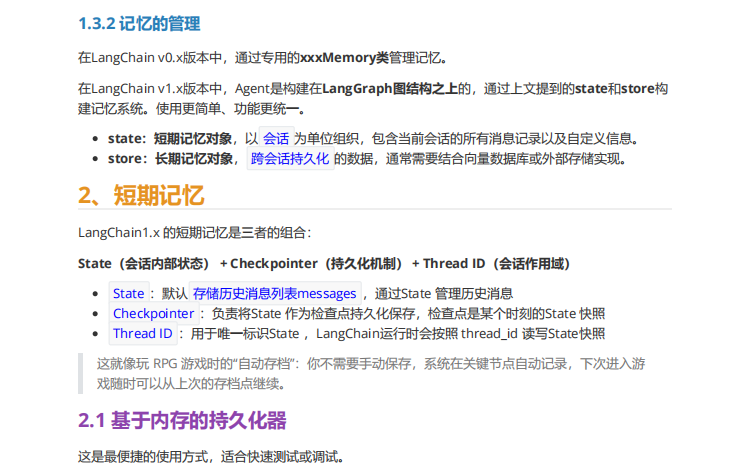

In [1]:
from langchain.chat_models import init_chat_model
from langchain.agents import create_agent
from dotenv import load_dotenv
import os

from langchain_core.messages import AIMessageChunk

load_dotenv(override=True)
DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_BASE_URL = "https://api.deepseek.com"
model = init_chat_model(
    model="deepseek:deepseek-v4-flash",
    api_key=DEEPSEEK_API_KEY,
    extra_body={"thinking": {"type": "disabled"}},  #关闭思考模式
)


In [2]:
from langchain_core.messages import HumanMessage
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()
# 1. 创建 Agent 时添加 checkpointer
agent = create_agent(
    model=model,
    checkpointer=checkpointer  # 添加内存管理
)
# 2. 调用时指定 thread_id
config = {
    "configurable": {
        "thread_id": "1"
    }
}
print("\n第一轮对话：")
response1 = agent.invoke({
    "messages": [HumanMessage("我叫张三")]},
    config=config  # 传入 config
)
print(f"Agent: {response1['messages'][-1].content}")
print("\n第二轮对话：")
response2 = agent.invoke({
    "messages": [HumanMessage("我叫什么？")]},
    config=config  # 使用相同的 thread_id
)
print(f"Agent: {response2['messages'][-1].content}")


第一轮对话：
Agent: 你好，张三！我是DeepSeek，很高兴认识你。😊

无论是想聊天、问问题、寻求建议，还是需要帮助解决某个具体问题，我都在这里。你可以随时告诉我你想聊什么或需要什么帮助！

比如：
- 想了解某个知识点？
- 需要写作或创作灵感？
- 遇到生活或工作上的难题？
- 或者只是想随便聊聊？

随时开口，我洗耳恭听！👂✨

第二轮对话：
Agent: 你刚才告诉我了，你叫**张三**。😊

不过，如果这是你随口说的昵称或者临时起的名字，也完全没问题——在咱们的对话里，我就当你叫张三啦！需要我帮你记住什么其他信息吗？


In [3]:
from rich import print as rprint
latest_state = agent.get_state(config)
rprint(latest_state)

StateSnapshot(
    values={
        'messages': [
            HumanMessage(
                content='我叫张三',
                additional_kwargs={},
                response_metadata={},
                id='6508589c-4680-41c8-b602-f62c76d31d70'
            ),
            AIMessage(
                content='你好，张三！我是DeepSeek，很高兴认识你。😊\n\n无论是想聊天、问问题、寻求建议，还是需要帮助
解决某个具体问题，我都在这里。你可以随时告诉我你想聊什么或需要什么帮助！\n\n比如：\n- 想了解某个知识点？\n- 
需要写作或创作灵感？\n- 遇到生活或工作上的难题？\n- 或者只是想随便聊聊？\n\n随时开口，我洗耳恭听！👂✨',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 94,
                        'prompt_tokens': 6,
                        'total_tokens': 100,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                        'prompt_cache_hit_tokens': 0,
                        'prompt_cache_miss_tokens': 6
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': '5fa328e9-4691-46e1-9304-c9e7d828c3dd',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--019f6fbe-78ff-7563-b7d3-1bef899fcdf9-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 6,
                    'output_tokens': 94,
                    'total_tokens': 100,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            ),
            HumanMessage(
                content='我叫什么？',
                additional_kwargs={},
                response_metadata={},
                id='785eceaa-2e15-4893-ab44-7c4a34fdb1ac'
            ),
            AIMessage(
                content='你刚才告诉我了，你叫**张三**。😊\n\n不过，如果这是你随口说的昵称或者临时起的名字，也完全没
问题——在咱们的对话里，我就当你叫张三啦！需要我帮你记住什么其他信息吗？',
                additional_kwargs={'refusal': None},
                response_metadata={
                    'token_usage': {
                        'completion_tokens': 53,
                        'prompt_tokens': 107,
                        'total_tokens': 160,
                        'completion_tokens_details': None,
                        'prompt_tokens_details': {'audio_tokens': None, 'cached_tokens': 0},
                        'prompt_cache_hit_tokens': 0,
                        'prompt_cache_miss_tokens': 107
                    },
                    'model_provider': 'deepseek',
                    'model_name': 'deepseek-v4-flash',
                    'system_fingerprint': 'fp_8b330d02d0_prod0820_fp8_kvcache_20260402',
                    'id': '4edf2c15-f1f2-40fa-a6b6-986bc98c896a',
                    'finish_reason': 'stop',
                    'logprobs': None
                },
                id='lc_run--019f6fbe-803d-7c30-b5cf-f0b9211b176f-0',
                tool_calls=[],
                invalid_tool_calls=[],
                usage_metadata={
                    'input_tokens': 107,
                    'output_tokens': 53,
                    'total_tokens': 160,
                    'input_token_details': {'cache_read': 0},
                    'output_token_details': {}
                }
            )
        ]
    },
    next=(),
    config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f181cf1-5f1c-61e9-8004-2f4ac4318c4e'
        }
    },
    metadata={'source': 'loop', 'step': 4, 'parents': {}},
    created_at='2026-07-17T11:03:05.157468+00:00',
    parent_config={
        'configurable': {
            'thread_id': '1',
            'checkpoint_ns': '',
            'checkpoint_id': '1f181cf1-4f25-63fd-8

说明：thread_id 隔离不同会话空间。 不同 thread_id 之间的记忆是独立的。

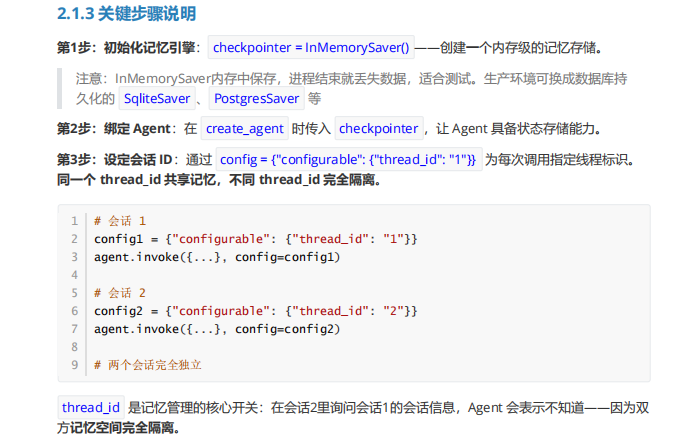
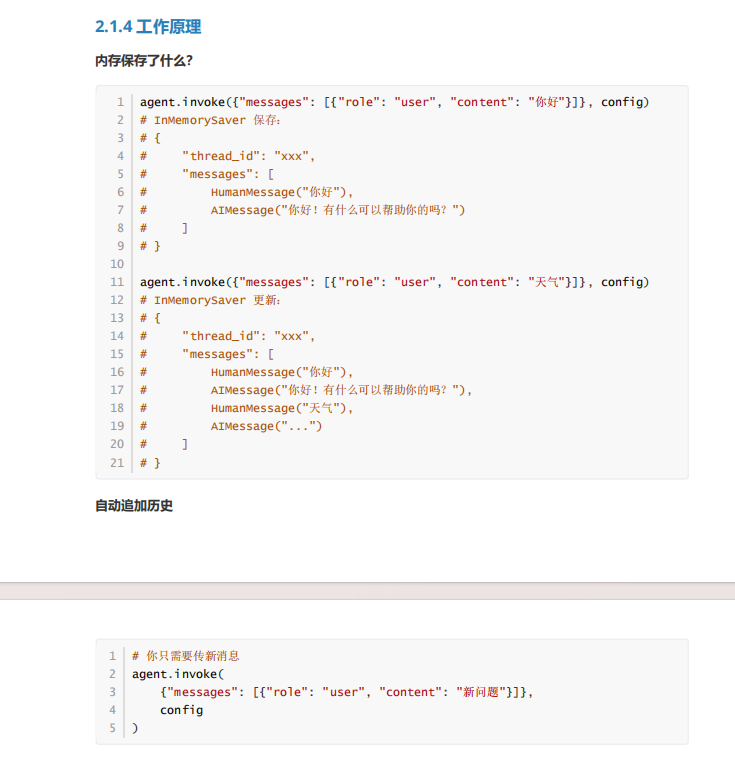
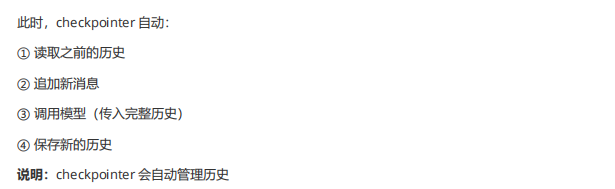
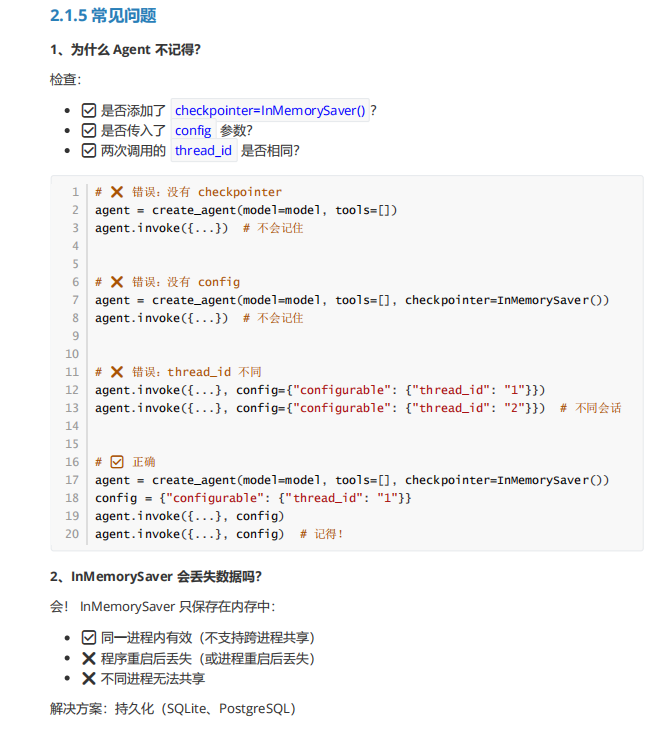
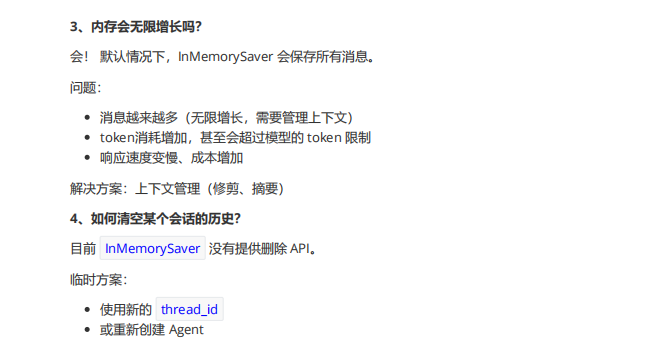
